### Load MITgcm Output from Assimilations

In [1]:
foldername = '/home/edavenport/analysis/vel-assim-manuscript/assimilation_results/'

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [3]:
from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/run_iter14/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

In [4]:
lon_str = '140'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_140 = xr.open_dataset(TAO_ADCP_file)

lon_str = '110'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_110 = xr.open_dataset(TAO_ADCP_file)

lon_str = '170'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_170 = xr.open_dataset(TAO_ADCP_file)

dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2013-06-30')) # subset to sep 2012, june 2013
dsTAO['u_1205'] = dsTAO.u_1205/100 # convert from cm/s to m/s
dsTAO['v_1206'] = dsTAO.v_1206/100 # convert from cm/s to m/s

/tmp/ipykernel_2174764/1577621949.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
/tmp/ipykernel_2174764/1577621949.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
/tmp/ipykernel_2174764/1577621949.py:13: FutureWarning: In a future version of xarra

In [5]:
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XG'})
tpose_U_noTAO = ds_tpose_noTAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()
tpose_U_TAO = ds_tpose_TAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()

# Propagate TAO NaNs into model so means are computed over the same time steps.
# Squeeze the mask to match the already-squeezed TPOSE arrays (removes singleton YC).
u_tao_mask = ~np.isnan(dsTAO.u_1205.squeeze())
tpose_U_noTAO = tpose_U_noTAO.where(u_tao_mask)
tpose_U_TAO   = tpose_U_TAO.where(u_tao_mask)

# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'XG':'XC','YC':'YG'})
tpose_V_noTAO = ds_tpose_noTAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()
tpose_V_TAO = ds_tpose_TAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()

# Propagate TAO NaNs into model so means are computed over the same time steps.
v_tao_mask = ~np.isnan(dsTAO.v_1206.squeeze())
tpose_V_noTAO = tpose_V_noTAO.where(v_tao_mask)
tpose_V_TAO   = tpose_V_TAO.where(v_tao_mask)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams['font.size'] = 13

fig = plt.figure(figsize=(14, 10))

gs = gridspec.GridSpec(
    4, 2,
    height_ratios=[1, 1, 1, 0.07],
    hspace=0.5,
    wspace=0.22
)

<Figure size 1400x1000 with 0 Axes>

In [7]:
# Create axes with shared x within each column
ax = np.empty((3, 2), dtype=object)

ax[0,0] = fig.add_subplot(gs[0,0])
ax[1,0] = fig.add_subplot(gs[1,0], sharex=ax[0,0])
ax[2,0] = fig.add_subplot(gs[2,0], sharex=ax[0,0])

ax[0,1] = fig.add_subplot(gs[0,1],sharey=ax[0,0])
ax[1,1] = fig.add_subplot(gs[1,1], sharex=ax[0,1], sharey=ax[1,0])
ax[2,1] = fig.add_subplot(gs[2,1], sharex=ax[0,1], sharey=ax[2,0])

vmin, vmax = -1.35, 1.35

# ----- Left column -----
mappable = (tpose_U_noTAO.sel(XG=190) - dsTAO.u_1205.sel(XC=190)).plot(
    ax=ax[0,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_noTAO.sel(XG=220) - dsTAO.u_1205.sel(XC=220)).plot(
    ax=ax[1,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_noTAO.sel(XG=250) - dsTAO.u_1205.sel(XC=250)).plot(
    ax=ax[2,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- Colorbar -----
cax = fig.add_subplot(gs[3, 0])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('TPOSE-noVel U - TAO U (m/s)')

vmin, vmax = -0.65, 0.65

# ----- Right column -----
mappable = (tpose_V_noTAO.sel(XC=190) - dsTAO.v_1206.sel(XC=190)).plot(
    ax=ax[0,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_noTAO.sel(XC=220) - dsTAO.v_1206.sel(XC=220)).plot(
    ax=ax[1,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_noTAO.sel(XC=250) - dsTAO.v_1206.sel(XC=250)).plot(
    ax=ax[2,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- Colorbar -----
cax = fig.add_subplot(gs[3, 1])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('TPOSE-noVel V - TAO V (m/s)')

for axis in ax.flatten():
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.set_title('')

ax[0,0].set_ylabel('Depth (m)')
ax[1,0].set_ylabel('Depth (m)')
ax[2,0].set_ylabel('Depth (m)')

ax[0,0].set_title('170W')
ax[0,1].set_title('170W')
ax[1,0].set_title('140W')
ax[1,1].set_title('140W')
ax[2,0].set_title('110W')
ax[2,1].set_title('110W')

plt.tight_layout()
fig.savefig(foldername+'velocity_diff_timeseries.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_2174764/2306308625.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


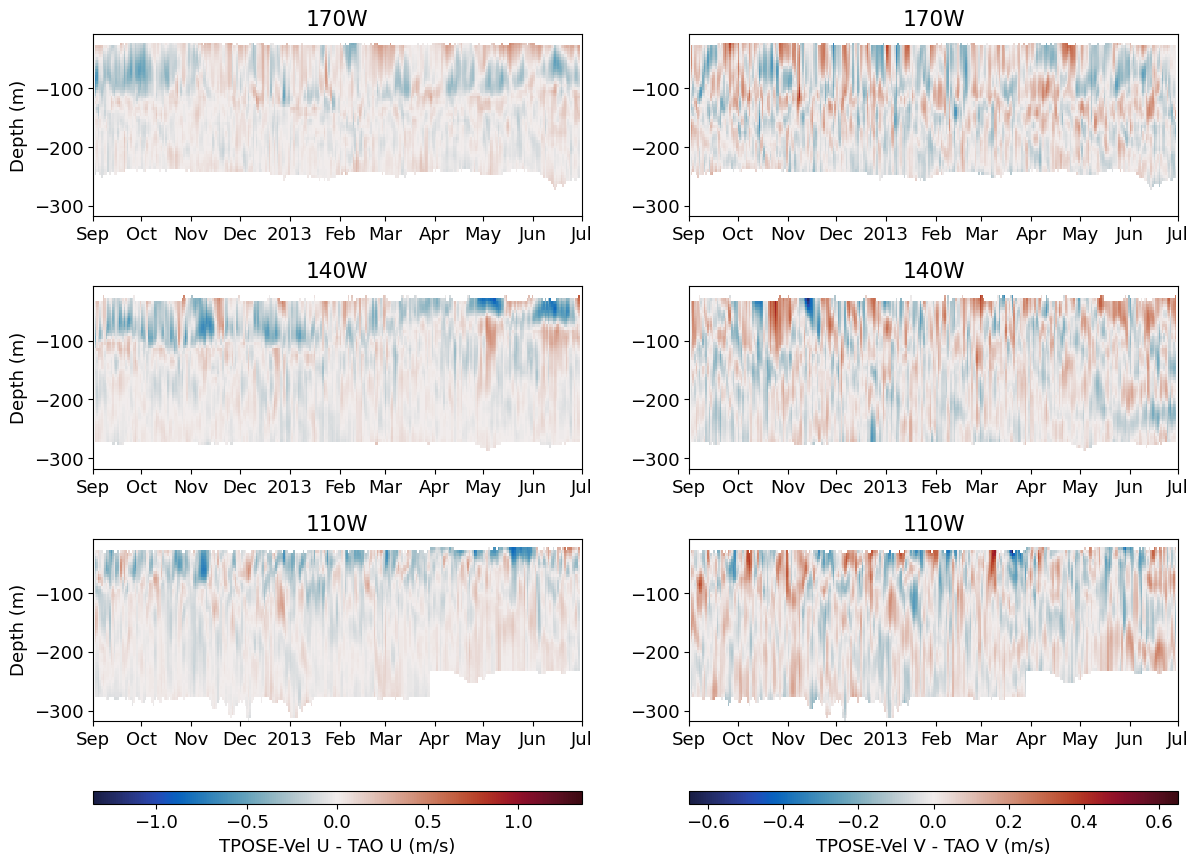

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams['font.size'] = 13

fig = plt.figure(figsize=(14, 10))

gs = gridspec.GridSpec(
    4, 2,
    height_ratios=[1, 1, 1, 0.07],
    hspace=0.5,
    wspace=0.22
)
# Create axes with shared x within each column
ax = np.empty((3, 2), dtype=object)

ax[0,0] = fig.add_subplot(gs[0,0])
ax[1,0] = fig.add_subplot(gs[1,0], sharex=ax[0,0])
ax[2,0] = fig.add_subplot(gs[2,0], sharex=ax[0,0])

ax[0,1] = fig.add_subplot(gs[0,1],sharey=ax[0,0])
ax[1,1] = fig.add_subplot(gs[1,1], sharex=ax[0,1], sharey=ax[1,0])
ax[2,1] = fig.add_subplot(gs[2,1], sharex=ax[0,1], sharey=ax[2,0])

vmin, vmax = -1.35, 1.35

# ----- Left column -----
mappable = (tpose_U_TAO.sel(XG=190) - dsTAO.u_1205.sel(XC=190)).plot(
    ax=ax[0,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_TAO.sel(XG=220) - dsTAO.u_1205.sel(XC=220)).plot(
    ax=ax[1,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_TAO.sel(XG=250) - dsTAO.u_1205.sel(XC=250)).plot(
    ax=ax[2,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- Colorbar -----
cax = fig.add_subplot(gs[3, 0])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('TPOSE-Vel U - TAO U (m/s)')

vmin, vmax = -0.65, 0.65

# ----- Right column -----
mappable = (tpose_V_TAO.sel(XC=190) - dsTAO.v_1206.sel(XC=190)).plot(
    ax=ax[0,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_TAO.sel(XC=220) - dsTAO.v_1206.sel(XC=220)).plot(
    ax=ax[1,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_TAO.sel(XC=250) - dsTAO.v_1206.sel(XC=250)).plot(
    ax=ax[2,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- Colorbar -----
cax = fig.add_subplot(gs[3, 1])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('TPOSE-Vel V - TAO V (m/s)')

for axis in ax.flatten():
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.set_title('')

ax[0,0].set_ylabel('Depth (m)')
ax[1,0].set_ylabel('Depth (m)')
ax[2,0].set_ylabel('Depth (m)')

ax[0,0].set_title('170W')
ax[0,1].set_title('170W')
ax[1,0].set_title('140W')
ax[1,1].set_title('140W')
ax[2,0].set_title('110W')
ax[2,1].set_title('110W')

plt.tight_layout()
fig.savefig(foldername+'velocity_diff_timeseries_TPOSE-Vel_update.png', bbox_inches='tight')

### Load TAO U and V

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams['font.size'] = 14
fig = plt.figure(figsize=(21, 21))

gs = gridspec.GridSpec(
    12, 3,
    height_ratios=[1, 1, 1, 0.1, 1, 1, 1, 0.1, 1, 1, 1, 0.1],
    width_ratios=[1, 1, 0.2],
    hspace=0.7,
    wspace=0.22
)

<Figure size 2100x2100 with 0 Axes>

In [14]:
lon_str = '170'
lon = 190
rows = np.arange(0,4,1)
vmin, vmax = -1.3, 1.3
lon_str = '140'
lon = 220
rows = np.arange(4,8,1)
vmin, vmax = -1.3, 1.3
lon_str = '110'
lon = 250
rows = np.arange(8,12,1)
vmin, vmax = -1.3, 1.3

In [15]:
# Create axes with shared x within each column
ax = np.empty((3, 3), dtype=object)

ax[0,0] = fig.add_subplot(gs[rows[0],0])
ax[1,0] = fig.add_subplot(gs[rows[1],0], sharex=ax[0,0])
ax[2,0] = fig.add_subplot(gs[rows[2],0], sharex=ax[0,0])

ax[0,1] = fig.add_subplot(gs[rows[0],1])
ax[1,1] = fig.add_subplot(gs[rows[1],1], sharex=ax[0,1])
ax[2,1] = fig.add_subplot(gs[rows[2],1], sharex=ax[0,1])

# these will be RMS profiles
ax[0,2] = fig.add_subplot(gs[rows[0],2])
ax[1,2] = fig.add_subplot(gs[rows[1],2])
ax[2,2] = fig.add_subplot(gs[rows[2],2])

# ----- Left column -----
mappable = dsTAO.u_1205.sel(XC=lon).plot(
    ax=ax[0,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_U_noTAO.sel(XG=lon).plot(
    ax=ax[1,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_noTAO.sel(XG=lon) - dsTAO.u_1205.sel(XC=lon)).plot(
    ax=ax[2,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- middle column -----
dsTAO.u_1205.sel(XC=lon).plot(
    ax=ax[0,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_U_TAO.sel(XG=lon).plot(
    ax=ax[1,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_TAO.sel(XG=lon) - dsTAO.u_1205.sel(XC=lon)).plot(
    ax=ax[2,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- right column -----
dsTAO.u_1205.sel(XC=lon).mean(dim='time').plot(ax=ax[0,2], y='Z',label='ADCP',color='tab:red')
ax[0,2].set_xlabel('U (m/s)',fontsize=13)
ax[0,2].set_title('')
ax[0,2].set_ylabel('')
ax[0,2].set_ylim(-250, -30)
ax[0,2].set_xlim(-0.5,1.5)
tpose_U_TAO.sel(XG=lon).mean(dim='time').plot(ax=ax[1,2], y='Z',label='TPOSE-Vel',color='tab:blue')
tpose_U_noTAO.sel(XG=lon).mean(dim='time').plot(ax=ax[1,2], y='Z',label='TPOSE-noVel',color='tab:orange')
# ax[1,2].legend()
ax[1,2].set_xlabel('U (m/s)',fontsize=13)
ax[1,2].set_title('')
ax[1,2].set_ylabel('')
ax[1,2].set_ylim(-250, -30)
ax[1,2].set_xlim(-0.5,1.5)
np.sqrt(((tpose_U_TAO.sel(XG=lon) - dsTAO.u_1205.sel(XC=lon))**2).mean(dim='time')).plot(ax=ax[2,2],y='Z',label='TPOSE-Vel',color='tab:blue')
np.sqrt(((tpose_U_noTAO.sel(XG=lon) - dsTAO.u_1205.sel(XC=lon))**2).mean(dim='time')).plot(ax=ax[2,2],y='Z',label='TPOSE-noVel',color='tab:orange')
# ax[2,2].legend()
ax[2,2].set_xlabel('RMSD (m/s)',fontsize=13)
ax[2,2].set_title('')
ax[2,2].set_ylabel('')
ax[2,2].set_ylim(-250, -20)
ax[2,2].set_xlim(0,0.75)

title = '0N, ' + lon_str + 'W'
# Remove titles everywhere
for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(-250, -30)
        ax[i,j].set_xlabel('')
        ax[i,j].text(
        0.99, 0.22, title,
        transform=ax[i, j].transAxes,
        ha='right', va='top',
        fontsize=14,
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='k',
            linewidth=0.5,
            alpha=1.0
        )
    )

# Remove y-labels on right column
for i in range(3):
    ax[i,1].set_ylabel('')
    ax[i,0].tick_params(labelbottom=False)
    ax[i,1].tick_params(labelbottom=False)

ax[2,0].tick_params(labelbottom=True)
ax[2,1].tick_params(labelbottom=True)

ax[0,0].set_title('ADCP')
ax[1,0].set_title('TPOSE-noVel')
ax[2,0].set_title('Difference')
ax[0,1].set_title('ADCP')
ax[1,1].set_title('TPOSE-Vel')
ax[2,1].set_title('Difference')

if lon==250:
    ax[2,2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.5), fontsize=13)

# ----- Colorbar -----
cax = fig.add_subplot(gs[rows[3], :-1])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('U (m/s)')

In [16]:
plt.tight_layout()
fig.savefig(foldername+'zonal_velocity.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Meridional Velocity

In [21]:
plt.rcParams['font.size'] = 14
fig = plt.figure(figsize=(16, 21))

gs = gridspec.GridSpec(
    12, 3,
    height_ratios=[1, 1, 1, 0.1, 1, 1, 1, 0.1, 1, 1, 1, 0.1],
    width_ratios=[1, 1, 0.2],
    hspace=0.7,
    wspace=0.22
)

<Figure size 1600x2100 with 0 Axes>

In [22]:
# lon_str = '170'
# lon = 190
# rows = np.arange(0,4,1)
# vmin, vmax = -0.4, 0.4
lon_str = '140'
lon = 220
rows = np.arange(4,8,1)
vmin, vmax = -0.5, 0.5
# lon_str = '110'
# lon = 250
# rows = np.arange(8,12,1)
# vmin, vmax = -0.55, 0.55

In [23]:
# Create axes with shared x within each column
ax = np.empty((3, 3), dtype=object)

ax[0,0] = fig.add_subplot(gs[rows[0],0])
ax[1,0] = fig.add_subplot(gs[rows[1],0], sharex=ax[0,0])
ax[2,0] = fig.add_subplot(gs[rows[2],0], sharex=ax[0,0])

ax[0,1] = fig.add_subplot(gs[rows[0],1])
ax[1,1] = fig.add_subplot(gs[rows[1],1], sharex=ax[0,1])
ax[2,1] = fig.add_subplot(gs[rows[2],1], sharex=ax[0,1])

# these will be RMS profiles
ax[0,2] = fig.add_subplot(gs[rows[0],2])
ax[1,2] = fig.add_subplot(gs[rows[1],2])
ax[2,2] = fig.add_subplot(gs[rows[2],2])

# ----- Left column -----
mappable = dsTAO.v_1206.sel(XC=lon).plot(
    ax=ax[0,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_V_noTAO.sel(XC=lon).plot(
    ax=ax[1,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_noTAO.sel(XC=lon) - dsTAO.v_1206.sel(XC=lon)).plot(
    ax=ax[2,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- middle column -----
dsTAO.v_1206.sel(XC=lon).plot(
    ax=ax[0,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_V_TAO.sel(XC=lon).plot(
    ax=ax[1,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_TAO.sel(XC=lon) - dsTAO.v_1206.sel(XC=lon)).plot(
    ax=ax[2,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- right column -----
dsTAO.v_1206.sel(XC=lon).mean(dim='time').plot(ax=ax[0,2], y='Z',label='ADCP',color='tab:red')
ax[0,2].set_xlabel('V (m/s)',fontsize=13)
ax[0,2].set_title('')
ax[0,2].set_ylabel('')
ax[0,2].set_ylim(-250, -30)
ax[0,2].set_xlim(-0.13,0.13)
tpose_V_TAO.sel(XC=lon).mean(dim='time').plot(ax=ax[1,2], y='Z',label='TPOSE-Vel',color='tab:blue')
tpose_V_noTAO.sel(XC=lon).mean(dim='time').plot(ax=ax[1,2], y='Z',label='TPOSE-noVel',color='tab:orange')
# ax[1,2].legend()
ax[1,2].set_xlabel('V (m/s)',fontsize=13)
ax[1,2].set_title('')
ax[1,2].set_ylabel('')
ax[1,2].set_ylim(-250, -30)
ax[1,2].set_xlim(-0.13,0.13)
np.sqrt(((tpose_V_TAO.sel(XC=lon) - dsTAO.v_1206.sel(XC=lon))**2).mean(dim='time')).plot(ax=ax[2,2],y='Z',label='TPOSE-Vel',color='tab:blue')
np.sqrt(((tpose_V_noTAO.sel(XC=lon) - dsTAO.v_1206.sel(XC=lon))**2).mean(dim='time')).plot(ax=ax[2,2],y='Z',label='TPOSE-noVel',color='tab:orange')
# ax[2,2].legend()
ax[2,2].set_xlabel('RMSD (m/s)',fontsize=13)
ax[2,2].set_title('')
ax[2,2].set_ylabel('')
ax[2,2].set_ylim(-250, -20)
ax[2,2].set_xlim(0,0.31)

title = '0N, ' + lon_str + 'W'
# Remove titles everywhere
for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(-250, -30)
        ax[i,j].set_xlabel('')
        ax[i,j].text(
        0.99, 0.22, title,
        transform=ax[i, j].transAxes,
        ha='right', va='top',
        fontsize=14,
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='k',
            linewidth=0.5,
            alpha=1.0
        )
    )

# Remove y-labels on right column
for i in range(3):
    ax[i,1].set_ylabel('')
    ax[i,0].tick_params(labelbottom=False)
    ax[i,1].tick_params(labelbottom=False)

ax[2,0].tick_params(labelbottom=True)
ax[2,1].tick_params(labelbottom=True)

ax[0,0].set_title('ADCP')
ax[1,0].set_title('TPOSE-noVel')
ax[2,0].set_title('Difference')
ax[0,1].set_title('ADCP')
ax[1,1].set_title('TPOSE-Vel')
ax[2,1].set_title('Difference')

if lon==250:
    ax[2,2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.5), fontsize=13)

# ----- Colorbar -----
cax = fig.add_subplot(gs[rows[3], :-1])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('V (m/s)')

In [24]:
plt.tight_layout()
fig.savefig(foldername+'meridional_velocity_140W.png',bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

### RMSD

In [25]:
def rmsd_calc(lon):
    rmsd_v = np.sqrt(((tpose_V_TAO.sel(XC=lon) - dsTAO.v_1206.sel(XC=lon))**2).mean())
    rmsd_u = np.sqrt(((tpose_U_TAO.sel(XG=lon) - dsTAO.u_1205.sel(XC=lon))**2).mean()) ## it isn't meaningful that one has XG and one has XC. the model has been interpolated to the data locations
    rmsd_v_noTAO = np.sqrt(((tpose_V_noTAO.sel(XC=lon) - dsTAO.v_1206.sel(XC=lon))**2).mean())
    rmsd_u_noTAO = np.sqrt(((tpose_U_noTAO.sel(XG=lon) - dsTAO.u_1205.sel(XC=lon))**2).mean())
    return rmsd_u, rmsd_v, rmsd_u_noTAO, rmsd_v_noTAO

In [26]:
rmsd_u_170, rmsd_v_170, rmsd_u_noTAO_170, rmsd_v_noTAO_170 = rmsd_calc(190)
rmsd_u_140, rmsd_v_140, rmsd_u_noTAO_140, rmsd_v_noTAO_140 = rmsd_calc(220)
rmsd_u_110, rmsd_v_110, rmsd_u_noTAO_110, rmsd_v_noTAO_110 = rmsd_calc(250)
# include % reduction 

print(f'RMSD U at 170W: TPOSE-Vel={rmsd_u_170:.3f} m/s, TPOSE-noVel={rmsd_u_noTAO_170:.3f} m/s, % change={(rmsd_u_170 - rmsd_u_noTAO_170)/rmsd_u_noTAO_170*100:.1f}%')
print(f'RMSD V at 170W: TPOSE-Vel={rmsd_v_170:.3f} m/s, TPOSE-noVel={rmsd_v_noTAO_170:.3f} m/s, % change={(rmsd_v_170 - rmsd_v_noTAO_170)/rmsd_v_noTAO_170*100:.1f}%')
print(f'RMSD U at 140W: TPOSE-Vel={rmsd_u_140:.3f} m/s, TPOSE-noVel={rmsd_u_noTAO_140:.3f} m/s, % change={(rmsd_u_140 - rmsd_u_noTAO_140)/rmsd_u_noTAO_140*100:.1f}%')
print(f'RMSD V at 140W: TPOSE-Vel={rmsd_v_140:.3f} m/s, TPOSE-noVel={rmsd_v_noTAO_140:.3f} m/s, % change={(rmsd_v_140 - rmsd_v_noTAO_140)/rmsd_v_noTAO_140*100:.1f}%')
print(f'RMSD U at 110W: TPOSE-Vel={rmsd_u_110:.3f} m/s, TPOSE-noVel={rmsd_u_noTAO_110:.3f} m/s, % change={(rmsd_u_110 - rmsd_u_noTAO_110)/rmsd_u_noTAO_110*100:.1f}%')
print(f'RMSD V at 110W: TPOSE-Vel={rmsd_v_110:.3f} m/s, TPOSE-noVel={rmsd_v_noTAO_110:.3f} m/s, % change={(rmsd_v_110 - rmsd_v_noTAO_110)/rmsd_v_noTAO_110*100:.1f}%')

RMSD U at 170W: TPOSE-Vel=0.103 m/s, TPOSE-noVel=0.279 m/s, % change=-63.1%
RMSD V at 170W: TPOSE-Vel=0.086 m/s, TPOSE-noVel=0.113 m/s, % change=-24.5%
RMSD U at 140W: TPOSE-Vel=0.137 m/s, TPOSE-noVel=0.316 m/s, % change=-56.8%
RMSD V at 140W: TPOSE-Vel=0.084 m/s, TPOSE-noVel=0.125 m/s, % change=-32.5%
RMSD U at 110W: TPOSE-Vel=0.114 m/s, TPOSE-noVel=0.223 m/s, % change=-49.1%
RMSD V at 110W: TPOSE-Vel=0.081 m/s, TPOSE-noVel=0.154 m/s, % change=-47.1%
